<a href="https://colab.research.google.com/github/Raajarapu/COLAB_practice/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Definition
A **Recurrent Neural Network (RNN)** is a type of artificial neural network designed to recognize patterns in sequences of data, such as time series, speech, or text. Unlike traditional feedforward neural networks, RNNs have loops, enabling them to process sequences by maintaining a "memory" of previous inputs through hidden states.

### Purpose
RNNs are primarily used to model and process data with a sequential dependency, meaning each data point in a sequence relates to others in the sequence. This makes them ideal for tasks like:
- Natural Language Processing (e.g., translation, sentiment analysis).
- Speech Recognition and Generation.
- Time Series Prediction (e.g., stock prices, weather forecasts).
- Sequential Data Analysis (e.g., handwriting recognition, video analysis).

### Advantages
- **Sequence modeling:** RNNs are particularly suited for sequence prediction problems.
- **Memory:** They retain and utilize information from previous steps, making them efficient for tasks requiring temporal context.
- **Flexibility:** They can handle inputs of variable lengths, such as paragraphs or audio streams.
- **Time dependency:** They consider time-dependent relationships in data.

### Disadvantages
- **Vanishing gradient problem:** During training, gradients can become very small, making it hard to update weights, especially for long sequences.
- **Exploding gradients:** Gradients can also grow too large, causing instability in the model.
- **Computational inefficiency:** Sequential processing makes them slower to train compared to feedforward neural networks.
- **Limited memory:** Standard RNNs struggle with very long sequences due to their short-term memory.

### Assumptions
RNNs generally assume:
1. Sequential dependency exists in the input data.
2. Data is processed one step at a time, maintaining a temporal connection between steps.
3. Hidden states effectively summarize prior information for prediction or decision-making.

### Limitations
- Difficulty in capturing long-term dependencies (though improved with LSTMs and GRUs).
- Require a lot of training data to perform effectively.
- Susceptible to overfitting when working with small datasets.

### Types of RNN
1. **Vanilla RNNs:** The simplest form, where inputs and hidden states are processed linearly.
2. **Long Short-Term Memory (LSTM):** A type of RNN designed to address the vanishing gradient problem by introducing gates (forget, input, and output gates).
3. **Gated Recurrent Unit (GRU):** A simplified version of LSTMs with fewer gates, making them computationally lighter.
4. **Bidirectional RNNs:** These process sequences in both forward and backward directions for better context understanding.
5. **Deep RNNs:** Composed of multiple RNN layers to capture complex temporal patterns.

### Functions Used in RNNs
- **Activation functions:**
  - **Sigmoid:** For binary outputs or gated mechanisms (e.g., in LSTMs or GRUs).
  - **Tanh:** Commonly used for the hidden state activation function.
  - **ReLU (Rectified Linear Unit):** Occasionally used to combat vanishing gradients.
- **Loss functions:**
  - Mean Squared Error (MSE): For regression tasks.
  - Cross-Entropy Loss: For classification tasks (e.g., text sentiment analysis).

### Detailed Explanation of RNNs
At their core, RNNs process inputs sequentially. At each time step, an RNN takes an input vector and combines it with the hidden state from the previous step, producing a new hidden state. The output of an RNN can either be generated at every time step (e.g., for sequence generation) or just at the end (e.g., for sequence classification). The hidden state acts as a memory, summarizing information from earlier steps.

For longer sequences, the **vanishing gradient problem** occurs during backpropagation through time (BPTT), the algorithm used to train RNNs. To mitigate this, LSTMs and GRUs were introduced with mechanisms to control the flow of information and remember relevant inputs for longer durations.


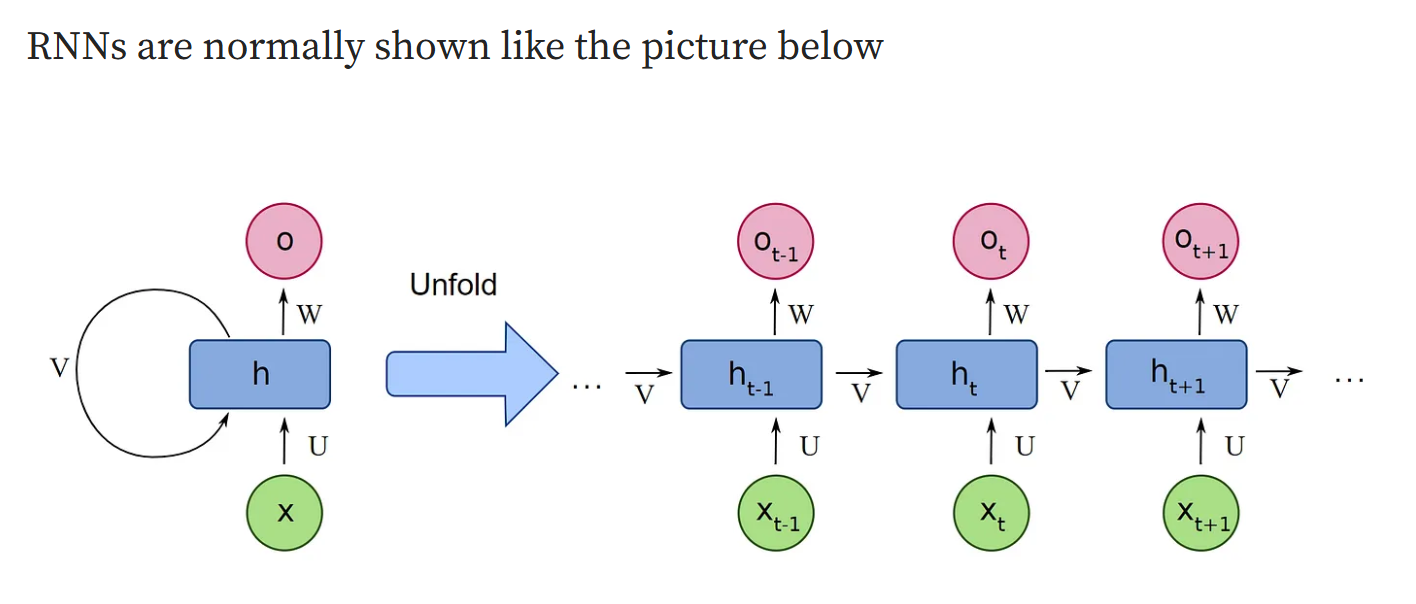

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
data = pd.read_csv("seattle-weather.csv")
data

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun


In [ ]:
data.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [ ]:
data.tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun
1460,2015-12-31,0.0,5.6,-2.1,3.5,sun


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [ ]:
data.isna().sum()

,0
date,0
precipitation,0
temp_max,0
temp_min,0
wind,0
weather,0


In [ ]:
data.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [ ]:
data.shape

(1461, 6)

In [ ]:
data.columns

Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')

# Univariate Analysis
## Visualizing Distributions

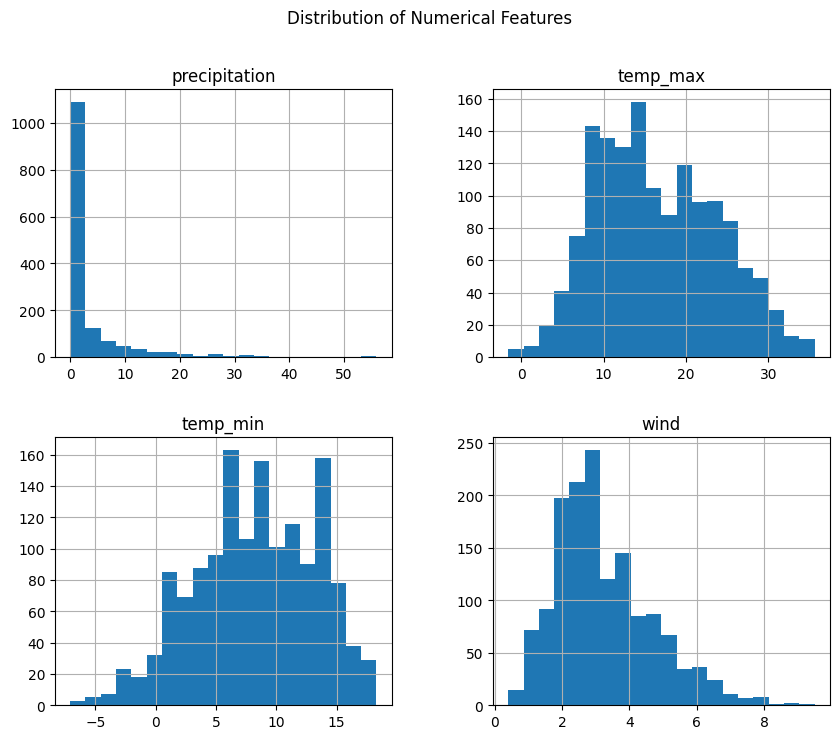

In [ ]:
# Histograms for numerical columns
import matplotlib.pyplot as plt
data[['precipitation', 'temp_max', 'temp_min', 'wind']].hist(bins=20, figsize=(10, 8))
plt.suptitle("Distribution of Numerical Features")
plt.show()

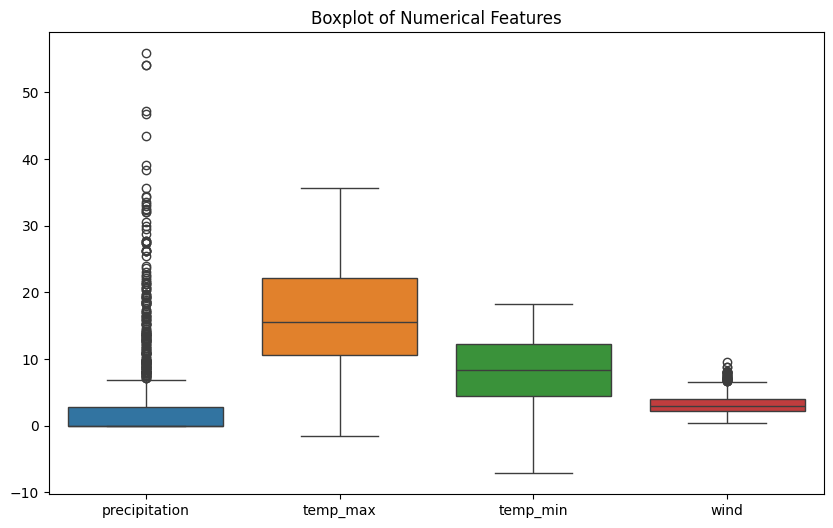

In [ ]:
# Boxplots for spread and outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=data[['precipitation', 'temp_max', 'temp_min', 'wind']])
plt.title("Boxplot of Numerical Features")
plt.show()

# Density Plots

<ipython-input-15-755d46ed2a30>:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data[column], shade=True, label=column)
<ipython-input-15-755d46ed2a30>:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data[column], shade=True, label=column)
<ipython-input-15-755d46ed2a30>:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data[column], shade=True, label=column)
<ipython-input-15-755d46ed2a30>:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data[column], shade=True, label=column)


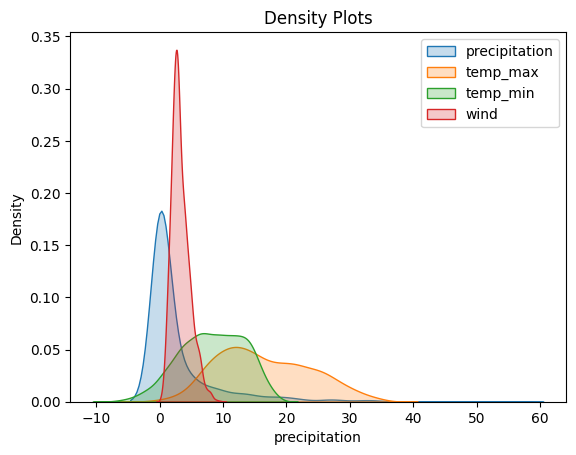

In [ ]:
# Density plots for continuous variables
for column in ['precipitation', 'temp_max', 'temp_min', 'wind']:
    sns.kdeplot(data[column], shade=True, label=column)
plt.title("Density Plots")
plt.legend()
plt.show()

# Scatter Plots to Explore Relationships

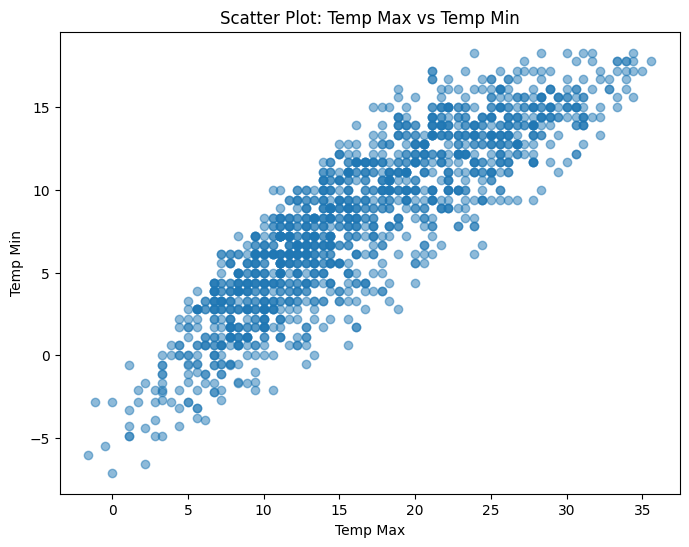

In [ ]:
# Scatter plot for temp_max vs temp_min
plt.figure(figsize=(8, 6))
plt.scatter(data['temp_max'], data['temp_min'], alpha=0.5)
plt.xlabel("Temp Max")
plt.ylabel("Temp Min")
plt.title("Scatter Plot: Temp Max vs Temp Min")
plt.show()


# Correlation Heatmap

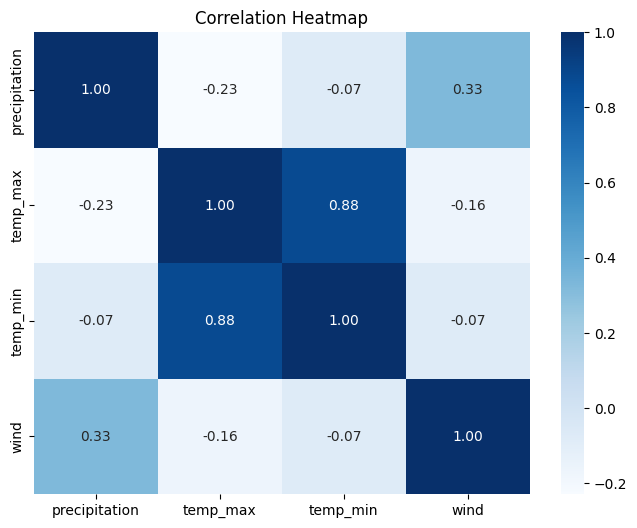

In [ ]:
# Correlation matrix and heatmap
correlation_matrix = data[['precipitation', 'temp_max', 'temp_min', 'wind']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()


# Categorical Analysis
Bar Charts

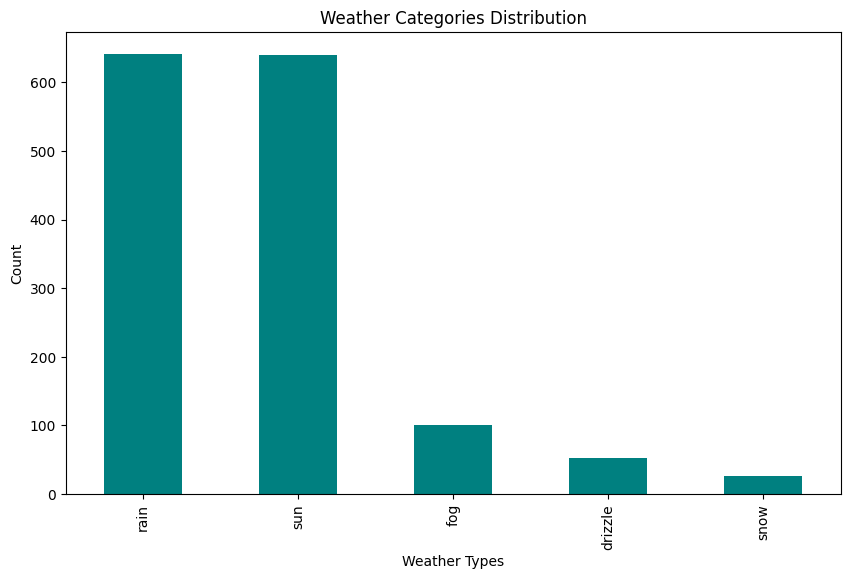

In [ ]:
# Bar plot for 'weather' column
plt.figure(figsize=(10, 6))
data['weather'].value_counts().plot(kind='bar', color='teal')
plt.title("Weather Categories Distribution")
plt.xlabel("Weather Types")
plt.ylabel("Count")
plt.show()


# Data Preprocessing for RNN
## Convert Date and Normalize Numerical Features

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Convert 'date' to datetime
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(by='date')  # Ensure data is sorted by date

# Normalize numerical columns
scaler = MinMaxScaler()
numerical_cols = ['precipitation', 'temp_max', 'temp_min', 'wind']
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

# One-hot encode 'weather' if necessary
data = pd.get_dummies(data, columns=['weather'], drop_first=True)


# Sequence Generation for RNN
## Creating Sliding Window Sequences

In [ ]:
# Define sequence length
sequence_length = 30  # Using 30 days as input sequence

# Convert data to sequences
X, y = [], []
features = data[numerical_cols].values  # Only normalized numerical columns are used
for i in range(len(features) - sequence_length):
    X.append(features[i:i + sequence_length])  # Input sequence (30 days)
    y.append(features[i + sequence_length][1])  # Target: temp_max (example)

X = np.array(X)
y = np.array(y)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Input Shape: {X_train.shape}, Target Shape: {y_train.shape}")


Input Shape: (1144, 30, 4), Target Shape: (1144,)


In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense


# Define the RNN Model

In [ ]:
# Define the RNN model
model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)  # Single output (e.g., predicting temp_max)
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Summary of the model
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,750 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,801 (10.94 KB)

 Trainable params: 2,801 (10.94 KB)

 Non-trainable params: 0 (0.00 B)

# Train the RNN

In [ ]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=20,  # Number of training iterations
    batch_size=32,  # Number of samples per batch
    validation_data=(X_test, y_test),  # Use test data for validation
    verbose=1  # Show training progress
)


Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.3709 - mae: 0.4325 - val_loss: 0.0235 - val_mae: 0.1227
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0167 - mae: 0.1021 - val_loss: 0.0137 - val_mae: 0.0909
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0141 - mae: 0.0944 - val_loss: 0.0102 - val_mae: 0.0789
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0099 - mae: 0.0782 - val_loss: 0.0090 - val_mae: 0.0744
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0087 - mae: 0.0728 - val_loss: 0.0080 - val_mae: 0.0708
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0084 - mae: 0.0729 - val_loss: 0.0089 - val_mae: 0.0758
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0081 - mae: 0.0711 - val_loss: 0.0072 - val_mae: 0.0682
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0073 - mae: 0.0686 - val_loss: 0.0068 - val_mae: 0.0664
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0070 - mae:

# Evaluate the Model

In [ ]:
# Evaluate the model on test data
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=1)

print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0060 - mae: 0.0636 
Test Loss (MSE): 0.0062
Test MAE: 0.0647


# Visualize Training Progress

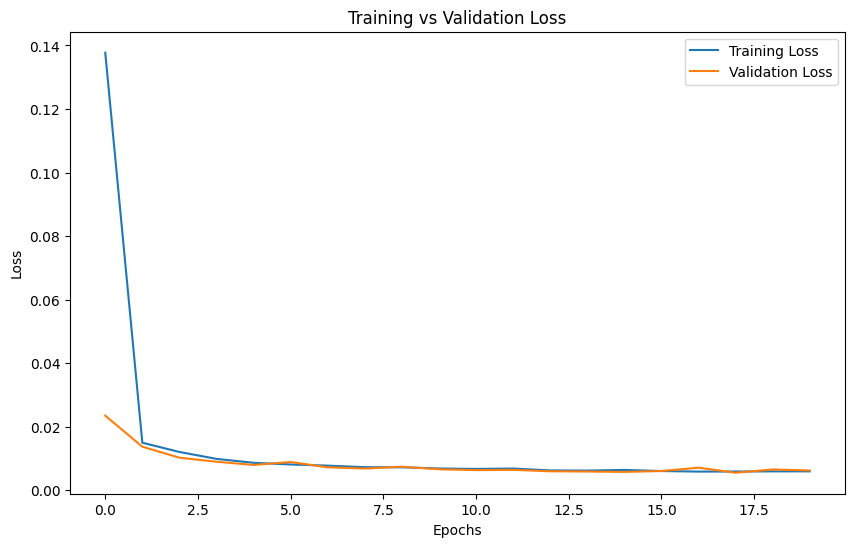

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Make Predictions

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


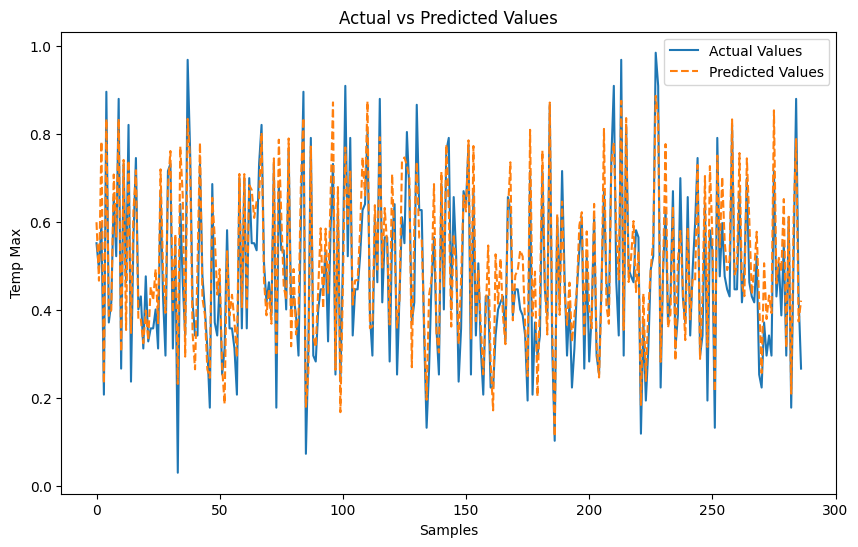

In [ ]:
# Make predictions on test data
predictions = model.predict(X_test)

# Visualize actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label="Actual Values")
plt.plot(predictions, label="Predicted Values", linestyle='dashed')
plt.title("Actual vs Predicted Values")
plt.xlabel("Samples")
plt.ylabel("Temp Max")
plt.legend()
plt.show()


# Vanilla RNN

### Vanilla Recurrent Neural Networks (RNNs)



---

#### **Definition**
A **Vanilla RNN** is the simplest form of a Recurrent Neural Network. It processes sequential data by maintaining a hidden state that acts as memory, allowing the network to incorporate information from previous steps when processing the current input. Its architecture consists of:
1. **Input Layer**: Accepts input data (sequence).
2. **Hidden Layer**: Includes recurrent connections, meaning the output of the previous step (hidden state) is fed back as an input for the next step.
3. **Output Layer**: Produces predictions based on the sequence processed.

The term "Vanilla" emphasizes that it is a basic RNN, without enhancements like Long Short-Term Memory (LSTM) or Gated Recurrent Units (GRU).

---

#### **Purpose**
Vanilla RNNs are used to process and model sequential data, where there is a dependency between current and prior inputs. They excel in tasks requiring understanding of the temporal sequence or time dependency, such as:
- **Time Series Forecasting**: Predicting stock prices or weather patterns.
- **Natural Language Processing (NLP)**: Tasks like text generation, machine translation, or sentiment analysis.
- **Speech Recognition**: Identifying spoken words or phrases.
- **Sequential Data Analysis**: Tasks like music generation, or analyzing user behavior patterns.

---

#### **Advantages**
1. **Handles Sequential Data**: Designed for datasets with temporal dependencies.
2. **Simplicity**: Basic implementation makes it easy to understand and deploy.
3. **Efficient for Short Sequences**: Performs well when sequence length is small and dependencies are local.
4. **End-to-End Learning**: Able to directly map input sequences to output sequences or predictions.

---

#### **Disadvantages**
1. **Vanishing Gradient Problem**: During backpropagation through time (BPTT), gradients can become very small, preventing effective training for long sequences.
2. **Exploding Gradient Problem**: Gradients can grow too large, causing instability in training.
3. **Limited Memory**: Struggles to capture long-term dependencies due to the simplicity of its architecture.
4. **Training Complexity**: Sequential processing makes training slower compared to feedforward networks.
5. **Sensitivity to Initialization**: Model performance heavily depends on the initial parameter values.

---

#### **Limitations**
1. **Short-Term Memory**: Cannot retain information across very long sequences.
2. **Scaling Issues**: Computationally intensive for large datasets or long sequences.
3. **Non-Stationary Inputs**: Less effective for inputs where patterns change significantly over time.
4. **Cannot Handle Missing Data**: Requires complete sequences for accurate predictions.

---

#### **Assumptions**
1. **Sequential Dependency**: The data being modeled has a temporal or sequential relationship.
2. **Fixed Input Size**: Input sequences need to be preprocessed to a uniform length (through truncation or padding).
3. **Linear Relationships**: Assumes the recurrent connections effectively summarize relevant past information.

---

#### **Range**
The **range** of a Vanilla RNN typically refers to:
1. **Input Sequence Length**: Works well with shorter sequences; struggles with very long ones.
2. **Output**: Can predict numerical values (regression), probabilities (classification), or sequences (text generation).
3. **Parameters**: Number of learnable weights is smaller compared to LSTM/GRU, making it computationally lighter.

---

#### **When It Is Used**
Vanilla RNNs are used when:
- The sequence lengths are short (e.g., <50 steps).
- Temporal dependencies are local and do not require long-term context.
- The goal is to experiment with or understand a basic RNN structure before moving to advanced models like LSTM or GRU.

---

#### **Detailed Explanation**
Vanilla RNNs operate by iteratively applying a recurrence relation to the input sequence. At each timestep:
1. The network takes an input vector.
2. Combines it with the hidden state from the previous timestep using learned weights and an activation function (e.g., tanh or ReLU).
3. Produces a new hidden state, which encodes information from the current input and past inputs.
4. The hidden state can then be used to generate an output (e.g., a prediction for the current time step).

The hidden state is updated as:
$$ h_t = f(W_{ih} \cdot x_t + W_{hh} \cdot h_{t-1} + b_h) $$
Where:
- \( x_t \): Current input.
- \( h_{t-1} \): Previous hidden state.
- \( W_{ih}, W_{hh} \): Input-hidden and hidden-hidden weight matrices.
- \( b_h \): Bias term.
- \( f \): Activation function (e.g., tanh).

During training, errors are backpropagated through all timesteps (BPTT), which adjusts weights to minimize loss. However, gradients can decay or explode during this process, limiting the network's effectiveness for long-term dependencies.



In [ ]:
from keras.layers import SimpleRNN

# Define and compile the Vanilla RNN model
vanilla_rnn = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)  # Single output for regression
])

vanilla_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
vanilla_rnn.summary()

# Train the Vanilla RNN
vanilla_rnn.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_9 (SimpleRNN)             │ (None, 50)                  │           2,750 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,801 (10.94 KB)

 Trainable params: 2,801 (10.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0442 - mae: 0.1608 - val_loss: 0.0133 - val_mae: 0.0901
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0106 - mae: 0.0821 - val_loss: 0.0093 - val_mae: 0.0778
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0086 - mae: 0.0741 - val_loss: 0.0077 - val_mae: 0.0702
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0069 - mae: 0.0668 - val_loss: 0.0071 - val_mae: 0.0674
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0064 - mae: 0.0636 - val_loss: 0.0067 - val_mae: 0.0655
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0066 - mae: 0.0652 - val_loss: 0.0063 - val_mae: 0.0640
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0062 - mae: 0.0628 - val_loss: 0.0062 - val_mae: 0.0644
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0054 - mae: 0.0582 - val_loss: 0.0060 - val_mae: 0.0627
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0060 - ma

# Long Short-Term Memory (LSTM)

### Long Short-Term Memory (LSTM) Networks



---

#### **Definition**
A **Long Short-Term Memory (LSTM)** is a specialized type of Recurrent Neural Network (RNN) designed to model both short-term and long-term dependencies in sequential data. Unlike Vanilla RNNs, LSTMs address the **vanishing gradient problem** by introducing a sophisticated mechanism that controls the flow of information using "gates."

The architecture includes:
1. **Forget Gate**: Decides which information from the previous cell state to discard.
2. **Input Gate**: Determines which new information to store in the cell state.
3. **Output Gate**: Controls the amount of information from the cell state to output at the current step.

These gates, combined with the cell state, enable LSTMs to "remember" or "forget" information over long sequences efficiently.

---

#### **Purpose**
LSTMs are used to model sequential data where long-term dependencies are critical. They are ideal for tasks where patterns appear over extended time spans, such as:
- **Natural Language Processing (NLP)**: Machine translation, text summarization, and chatbot development.
- **Speech Recognition**: Converting spoken words into text.
- **Time Series Forecasting**: Predicting future values in stock prices, weather conditions, or energy consumption.
- **Video Analysis**: Analyzing temporal patterns in videos for object tracking or action recognition.
- **Music Composition**: Generating sequences of musical notes based on previous patterns.

---

#### **Advantages**
1. **Long-Term Dependency Modeling**: Captures relationships across long sequences of data.
2. **Resilience to Vanishing Gradients**: The cell state and gating mechanisms mitigate issues associated with gradient decay during training.
3. **Flexible Memory**: The forget gate allows selective memory retention, making LSTMs adaptable to complex data patterns.
4. **Versatility**: Can handle varying sequence lengths without predefined constraints.

---

#### **Disadvantages**
1. **Computationally Intensive**: LSTMs have more parameters compared to Vanilla RNNs, which increases training time.
2. **Risk of Overfitting**: Requires regularization techniques like dropout to prevent the model from overfitting on training data.
3. **Data Dependency**: Needs a large amount of data to perform well, especially for complex tasks.
4. **Complex Architecture**: More challenging to understand and implement compared to simpler RNNs.

---

#### **Limitations**
1. **Scalability Issues**: Computational cost grows significantly with the sequence length and size of the data.
2. **Limited Interpretability**: Difficult to intuitively understand why certain sequences are remembered or forgotten due to the gating mechanisms.
3. **Sensitivity to Hyperparameters**: LSTMs require careful tuning of parameters like learning rate, number of layers, and units.

---

#### **Assumptions**
1. **Sequential Dependencies**: Data points have temporal or sequential relationships that need to be captured.
2. **Sufficient Data**: A large dataset is assumed for effective training and avoidance of overfitting.
3. **Normalized Inputs**: Inputs must be preprocessed, such as normalization or standardization, for optimal performance.

---

#### **Range**
The **range** of an LSTM model typically refers to:
1. **Input Sequence Length**: Performs well on sequences ranging from short to long, thanks to its ability to selectively retain or forget information.
2. **Output Types**: Can generate outputs for regression (numeric predictions), classification (categorical outputs), or sequential outputs (e.g., text generation).
3. **Applications**: Used across domains, from NLP and time series forecasting to video and image sequence modeling.

---

#### **When It Is Used**
LSTMs are used when:
1. **Long-Term Dependencies Matter**: If patterns span large intervals (e.g., translating a sentence with context from previous words).
2. **Sequential Data Complexity**: When the sequence involves intricate temporal relationships, such as in speech or audio data.
3. **Standard RNNs Fail**: LSTMs are a go-to solution for overcoming the vanishing gradient issue in Vanilla RNNs.

---

#### **Detailed Explanation**
At each timestep, an LSTM unit processes the input, hidden state, and cell state using its three gates:
1. **Forget Gate (\(f_t\))**:
   - Decides how much of the previous cell state (\(C_{t-1}\)) to retain.
   - \( f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \)

2. **Input Gate (\(i_t\)) and Candidate Memory (\(\tilde{C}_t\))**:
   - Determines what new information to add to the cell state.
   - \( i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \)
   - \( \tilde{C}_t = \text{tanh}(W_C \cdot [h_{t-1}, x_t] + b_C) \)

3. **Cell State (\(C_t\)) Update**:
   - Combines the retained memory and the new input.
   - \( C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t \)

4. **Output Gate (\(o_t\)) and Final Hidden State (\(h_t\))**:
   - Produces the hidden state and output for the current timestep.
   - \( o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \)
   - \( h_t = o_t \cdot \text{tanh}(C_t) \)



In [ ]:
from keras.layers import LSTM

# Define and compile the LSTM model
lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)  # Output layer
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

# Train the LSTM model
lstm_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 50)                  │          11,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,051 (43.17 KB)

 Trainable params: 11,051 (43.17 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0983 - mae: 0.2421 - val_loss: 0.0112 - val_mae: 0.0816
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0118 - mae: 0.0870 - val_loss: 0.0093 - val_mae: 0.0776
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0093 - mae: 0.0775 - val_loss: 0.0090 - val_mae: 0.0745
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0092 - mae: 0.0748 - val_loss: 0.0085 - val_mae: 0.0742
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0086 - mae: 0.0735 - val_loss: 0.0086 - val_mae: 0.0725
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0082 - mae: 0.0710 - val_loss: 0.0081 - val_mae: 0.0714
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0077 - mae: 0.0686 - val_loss: 0.0078 - val_mae: 0.0720
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0083 - mae: 0.0725 - val_loss: 0.0077 - val_mae: 0.0717
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.008

# Gated Recurrent Unit (GRU)



---

### **What is a GRU?**
A Gated Recurrent Unit (GRU) is a type of neural network designed for working with sequential data, like time series or text. It is similar to an LSTM but has a simpler structure, which makes it faster and easier to work with. Think of it as a smarter RNN (Recurrent Neural Network) that knows when to remember information and when to forget it.

---

### **Purpose**
GRUs are used to model relationships in data that evolve over time, such as predicting future values in stock prices, understanding the sentiment of a sentence, or recognizing spoken words.

---

### **How Does It Work?**
1. **Hidden State (Memory):** GRUs store information in their hidden state and update it step by step as they process a sequence.
2. **Gates (Decision Makers):**
   - **Update Gate:** Decides how much of the new information should be added to the memory.
   - **Reset Gate:** Controls how much of the past information should be forgotten.

These gates help the GRU decide what to "remember" or "forget" based on the data it's processing.

---

### **Advantages**
- **Simplicity:** GRUs are simpler than LSTMs because they have fewer components, making them faster to train.
- **Powerful Memory:** Can handle short and long-term patterns in data, like a memory that adjusts to what's important.
- **Efficient:** Works well on smaller datasets and is computationally less expensive than LSTMs.

---

### **Disadvantages**
- **Limited Flexibility:** GRUs might not be as powerful as LSTMs in handling very complex patterns.
- **No Separate Cell State:** Unlike LSTMs, GRUs don't have a separate cell state, which can sometimes limit their performance.

---

### **When Do We Use GRUs?**
- When you have sequential data (like stock prices, text, audio).
- When you need something faster and simpler than LSTMs.
- When long-term dependencies in your data aren't extremely complex.

---

### **Key Idea**
The GRU acts like a decision-maker for sequences. It decides what parts of the sequence to focus on (remember) and what to ignore (forget), and uses that information to make predictions or understand patterns.

---


In [ ]:
from keras.layers import GRU

# Define and compile the GRU model
gru_model = Sequential([
    GRU(50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
gru_model.summary()

# Train the GRU model
gru_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                          │ (None, 50)                  │           8,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,451 (33.01 KB)

 Trainable params: 8,451 (33.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.2623 - mae: 0.4107 - val_loss: 0.0147 - val_mae: 0.0924
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0164 - mae: 0.1011 - val_loss: 0.0108 - val_mae: 0.0814
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0116 - mae: 0.0855 - val_loss: 0.0088 - val_mae: 0.0748
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0094 - mae: 0.0764 - val_loss: 0.0082 - val_mae: 0.0723
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0084 - mae: 0.0731 - val_loss: 0.0078 - val_mae: 0.0711
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0081 - mae: 0.0714 - val_loss: 0.0075 - val_mae: 0.0694
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0075 - mae: 0.0686 - val_loss: 0.0072 - val_mae: 0.0689
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0068 - mae: 0.0662 - val_loss: 0.0070 - val_mae: 0.0674
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.006

# Bidirectional RNN

### Bidirectional Recurrent Neural Networks (Bidirectional RNNs)


---

### **What is a Bidirectional RNN?**
A **Bidirectional RNN** is an extension of a standard RNN where the network processes the input sequence in both directions: forward (from the beginning to the end of the sequence) and backward (from the end back to the beginning). This allows the model to capture information from both the past and future of a sequence, providing better context and improving prediction accuracy for certain tasks.

In essence:
- **Forward Pass**: The RNN processes the sequence in its natural order.
- **Backward Pass**: The RNN simultaneously processes the sequence in reverse.
- The outputs from both directions are combined, typically by concatenation.

---

### **Purpose**
The purpose of a Bidirectional RNN is to understand the full context of a sequence. For example:
- In **Natural Language Processing (NLP)**, understanding both previous words (context before a word) and future words (context after the word) helps tasks like machine translation or named entity recognition.
- In **Speech Recognition**, knowing the future sound signals alongside past sounds helps better identify words.
- For **Time Series Analysis**, it leverages patterns occurring before and after a particular time step to improve accuracy.

---

### **How Does It Work?**
1. The sequence is processed twice:
   - Once in the forward direction.
   - Once in the backward direction.
2. Each direction maintains its own hidden states.
3. The outputs from the two directions are then combined, typically by concatenation or summation, and passed to the next layer.

---

### **Advantages**
1. **Full Sequence Context**: Captures both past (backward) and future (forward) dependencies, making it highly effective for sequential tasks.
2. **Improved Accuracy**: Enhances prediction by incorporating information from both directions.
3. **Versatility**: Can be applied to any sequence-based task, whether text, speech, or time series.

---

### **Disadvantages**
1. **Higher Computational Cost**: Processing data in two directions doubles the computational requirements compared to a standard RNN.
2. **Slower Training**: Due to the doubled operations and increased parameters.
3. **Not Ideal for Real-Time Use**: Since it requires the entire sequence (future data), it’s unsuitable for real-time tasks like streaming data prediction.

---

### **Limitations**
1. **Future Information Requirement**: To process the sequence backward, it requires knowledge of the entire sequence upfront, which may not be available in real-time scenarios.
2. **Memory Usage**: Processing data in both directions increases memory usage, which can be a concern for large datasets or long sequences.

---

### **Assumptions**
1. **Complete Data Availability**: Assumes that the full sequence is available at the time of processing.
2. **Sequential Dependency**: Assumes the input data contains dependencies across time (e.g., temporal data or text).
3. **Preprocessing**: Requires the input data to be cleaned, normalized, or padded for uniformity.

---

### **Range**
1. **Input Length**: Suitable for tasks where the entire input sequence is accessible.
2. **Applications**: Particularly effective for tasks like NLP, speech recognition, handwriting recognition, and text-to-speech processing.

---

### **When Is It Used?**
- **Text Analysis**: Understanding the complete meaning of words in a sentence by considering both preceding and succeeding words.
- **Speech Recognition**: Using the entire audio sequence to improve word or phrase identification.
- **Non-Real-Time Applications**: Where having access to the full sequence is not a constraint (e.g., batch processing of data).

---

### **Key Idea**
The Bidirectional RNN’s power lies in its ability to look at the "big picture" of a sequence. By considering both what comes before and after each step, it gains deeper context that improves the model’s understanding and prediction capability.


In [ ]:
from keras.layers import Bidirectional

# Define and compile the Bidirectional RNN model
bidirectional_rnn = Sequential([
    Bidirectional(SimpleRNN(50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2]))),
    Dense(1)
])

bidirectional_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
bidirectional_rnn.summary()

# Train the Bidirectional RNN
bidirectional_rnn.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0920 - mae: 0.2316 - val_loss: 0.0190 - val_mae: 0.1090
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0150 - mae: 0.0973 - val_loss: 0.0137 - val_mae: 0.0933
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0119 - mae: 0.0867 - val_loss: 0.0109 - val_mae: 0.0836
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0094 - mae: 0.0766 - val_loss: 0.0090 - val_mae: 0.0767
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0082 - mae: 0.0716 - val_loss: 0.0112 - val_mae: 0.0861
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0084 - mae: 0.0735 - val_loss: 0.0081 - val_mae: 0.0725
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0071 - mae: 0.0664 - val_loss: 0.0090 - val_mae: 0.0771
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0094 - mae: 0.0779 - val_loss: 0.0074 - val_mae: 0.0689
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.007

# Deep RNN (Stacked Layers)

### Deep RNN (Stacked Layers)


---

### **What is a Deep RNN (Stacked Layers)?**
A **Deep RNN** is an extension of the standard RNN where multiple RNN layers are stacked on top of each other. This stacking allows the model to learn more complex patterns in data because each layer processes the sequence at a higher level of abstraction.

- **Input Layer**: Receives the raw data.
- **Hidden Layers**: Stacked layers of RNNs, where each layer passes its output as input to the next layer.
- **Output Layer**: Provides the final prediction or output.

The idea is similar to Deep Neural Networks (DNNs) but applied to sequential data.

---

### **Purpose**
The purpose of a Deep RNN is to:
- Capture **hierarchical features** in sequential data.
- Model complex dependencies that cannot be captured by a single RNN layer.
- Improve performance on tasks like speech recognition, time series prediction, and natural language processing (NLP).

---

### **How Does It Work?**
1. **First RNN Layer**: Processes the input sequence and produces an output sequence.
2. **Intermediate RNN Layers**: Each layer takes the output of the previous layer and processes it further.
3. **Final Layer**: The last RNN layer outputs the predictions or passes data to a Dense layer for further processing.

This stacking enables the model to extract **low-level patterns** in initial layers and **high-level patterns** in deeper layers.

---

### **Advantages**
1. **Better Representation Learning**: Captures complex patterns by processing sequences at multiple levels.
2. **Improved Accuracy**: Stacked layers often lead to better performance on challenging tasks.
3. **Modularity**: Easy to combine with other advanced architectures, like LSTMs or GRUs.
4. **Versatility**: Applicable to a wide range of sequential tasks.

---

### **Disadvantages**
1. **Increased Complexity**: More layers mean more parameters to train, requiring more data and computational resources.
2. **Risk of Overfitting**: Higher model complexity increases the chance of overfitting, especially with limited data.
3. **Training Instability**: Deeper models can suffer from vanishing or exploding gradients.

---

### **Limitations**
1. **High Computational Cost**: Training deep RNNs requires significant computational power.
2. **Memory Requirements**: Storing and processing multiple layers simultaneously uses more memory.
3. **Difficult to Interpret**: As the number of layers increases, understanding how the model makes decisions becomes harder.

---

### **Assumptions**
1. **Sequential Dependencies**: Assumes the input data has sequential relationships.
2. **Large Datasets**: Deep RNNs require a considerable amount of training data to perform well.
3. **Proper Normalization**: Inputs need to be preprocessed, like normalization or scaling, for effective learning.

---

### **Range**
The **range** of a Deep RNN:
1. **Input Size**: Works with sequential data of varying lengths (e.g., time series, text, speech).
2. **Applications**: Commonly used in complex tasks requiring hierarchical feature extraction, such as video analysis, machine translation, and audio generation.

---

### **When It Is Used**
- When a simple RNN or single-layer model fails to capture intricate patterns in sequential data.
- For advanced tasks like **multi-step forecasting** or **language modeling** where deeper feature representations are critical.
- When you have a large dataset and sufficient computational resources to train a more complex model.

---

### **Key Idea**
A Deep RNN is like stacking multiple levels of understanding on top of each other. The lower layers understand basic features, while higher layers capture more abstract features. This allows the model to make better predictions or generate more accurate outputs.

---


In [ ]:
# Define and compile the Deep RNN model
deep_rnn = Sequential([
    SimpleRNN(50, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    SimpleRNN(50, activation='tanh'),  # Second RNN layer
    Dense(1)
])

deep_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
deep_rnn.summary()

# Train the Deep RNN model
deep_rnn.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_7 (SimpleRNN)             │ (None, 30, 50)              │           2,750 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_8 (SimpleRNN)             │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,851 (30.67 KB)

 Trainable params: 7,851 (30.67 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.2005 - mae: 0.3440 - val_loss: 0.0297 - val_mae: 0.1470
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0192 - mae: 0.1146 - val_loss: 0.0114 - val_mae: 0.0835
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0116 - mae: 0.0868 - val_loss: 0.0100 - val_mae: 0.0779
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0098 - mae: 0.0787 - val_loss: 0.0086 - val_mae: 0.0738
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0083 - mae: 0.0737 - val_loss: 0.0074 - val_mae: 0.0692
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0073 - mae: 0.0680 - val_loss: 0.0070 - val_mae: 0.0681
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0066 - mae: 0.0639 - val_loss: 0.0066 - val_mae: 0.0664
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0069 - mae: 0.0665 - val_loss: 0.0071 - val_mae: 0.0695
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.006

Here's your requested data in a table format:

| **Model Type**        | **Total Params** | **Trainable Params** | **Non-trainable Params** | **Memory (KB)** |
|------------------------|------------------|-----------------------|---------------------------|-----------------|
| Vanilla RNN           | 2,801           | 2,801                | 0                         | 10.94 KB        |
| LSTM                  | 11,051          | 11,051               | 0                         | 43.17 KB        |
| GRU                   | 8,451           | 8,451                | 0                         | 33.01 KB        |
| Bidirectional RNN     | 0               | 0                    | 0                         | 0.00 KB         |
| Deep RNN              | 7,851           | 7,851                | 0                         | 30.67 KB        |

**bold text**

In [ ]:
# Example: Prediction for Vanilla RNN
vanilla_predictions = vanilla_rnn.predict(X_test)
lstm_predictions = lstm_model.predict(X_test)
gru_predictions = gru_model.predict(X_test)
bidirectional_predictions = bidirectional_rnn.predict(X_test)
deep_rnn_predictions = deep_rnn.predict(X_test)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


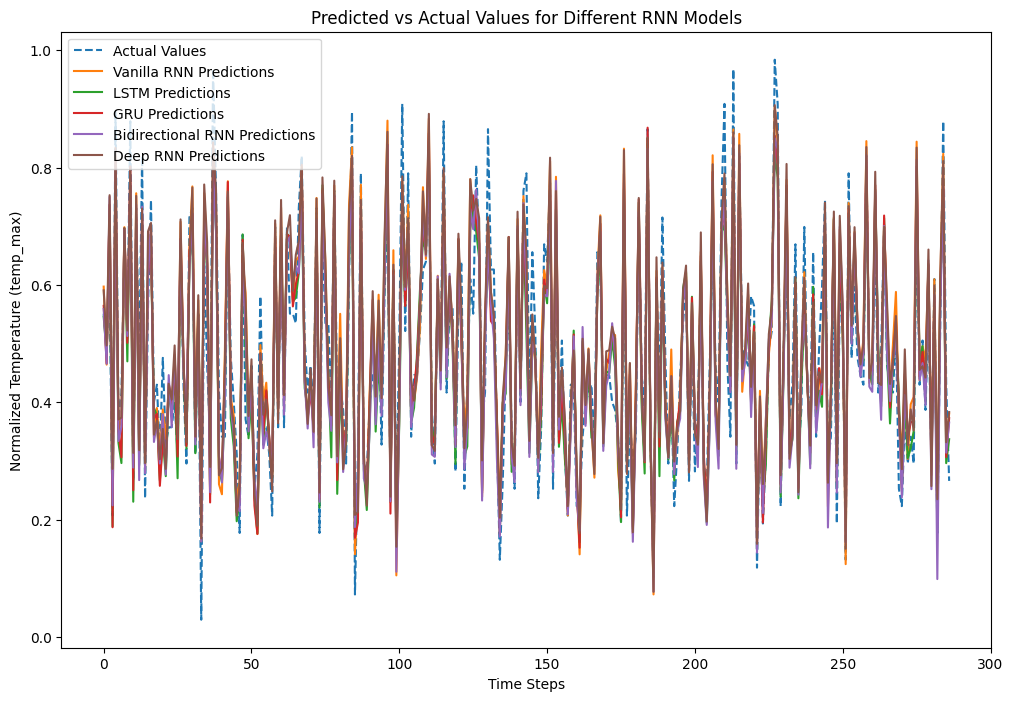

In [ ]:
import matplotlib.pyplot as plt

# Plot actual vs. predicted for all models
plt.figure(figsize=(12, 8))
plt.plot(y_test, label='Actual Values', linestyle='dashed')

# Add predictions from each model
plt.plot(vanilla_predictions, label='Vanilla RNN Predictions')
plt.plot(lstm_predictions, label='LSTM Predictions')
plt.plot(gru_predictions, label='GRU Predictions')
plt.plot(bidirectional_predictions, label='Bidirectional RNN Predictions')
plt.plot(deep_rnn_predictions, label='Deep RNN Predictions')

# Add labels and legend
plt.title("Predicted vs Actual Values for Different RNN Models")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Temperature (temp_max)")
plt.legend()
plt.show()


In [ ]:
print(history.history.keys())

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [ ]:
history = vanilla_rnn.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0049 - mae: 0.0550 - val_loss: 0.0067 - val_mae: 0.0669
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0050 - mae: 0.0556 - val_loss: 0.0057 - val_mae: 0.0625
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0051 - mae: 0.0558 - val_loss: 0.0057 - val_mae: 0.0625
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0048 - mae: 0.0534 - val_loss: 0.0060 - val_mae: 0.0636
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0043 - mae: 0.0516 - val_loss: 0.0066 - val_mae: 0.0665
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0051 - mae: 0.0561 - val_loss: 0.0060 - val_mae: 0.0639
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0050 - mae: 0.0551 - val_loss: 0.0062 - val_mae: 0.0652
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0048 - mae: 0.0544 - val_loss: 0.0058 - val_mae: 0.0637
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0047 - mae: 

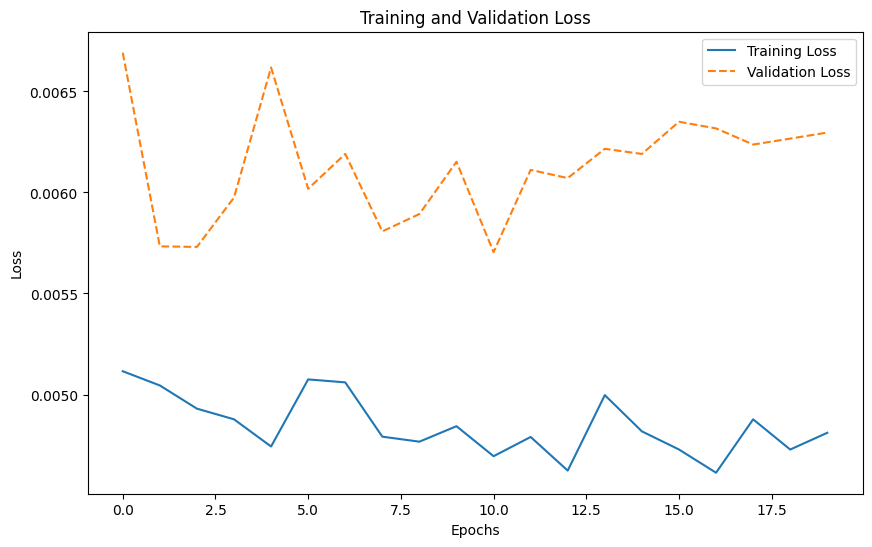

In [ ]:
plt.figure(figsize=(10, 6))

# Example for Vanilla RNN
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='dashed')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Conclusion:
### Comparative Insights and Summary of RNN Models

Recurrent Neural Networks (RNNs) have revolutionized the way we handle sequential data, offering unique capabilities for tasks involving temporal and sequential dependencies. From simple Vanilla RNNs to advanced models like LSTM, GRU, and Bidirectional RNNs, and the complex Deep RNNs, each has its strengths, weaknesses, and specific use cases. Here's a detailed conclusion based on the given table of parameters and memory values:

---

#### **1. Vanilla RNN**
- **Model Overview**: The simplest form of RNN with a straightforward architecture and fewer parameters.
- **Parameters**: With **2,801 trainable parameters** and a memory usage of **10.94 KB**, it is the lightest model in terms of computational cost.
- **Strengths**:
  - Effective for short sequences.
  - Computationally efficient and quick to train.
- **Weaknesses**:
  - Struggles with long-term dependencies due to the **vanishing gradient problem**.
  - Not ideal for complex sequences or datasets requiring a broader memory range.
- **Use Case**: Best for tasks where sequences are short, such as short text classification or short-term time series forecasting.

---

#### **2. Long Short-Term Memory (LSTM)**
- **Model Overview**: LSTMs are designed to overcome the limitations of Vanilla RNNs by using gates (forget, input, and output gates) and a dedicated cell state to retain long-term information.
- **Parameters**: With **11,051 trainable parameters** and a memory usage of **43.17 KB**, it is more resource-intensive but far more powerful.
- **Strengths**:
  - Captures both short-term and long-term dependencies efficiently.
  - Addresses the vanishing gradient problem, making it suitable for tasks requiring long-range memory.
- **Weaknesses**:
  - High computational cost and slower training.
  - Risk of overfitting without proper regularization techniques.
- **Use Case**: Ideal for applications like machine translation, text generation, and long-term time series forecasting.

---

#### **3. Gated Recurrent Unit (GRU)**
- **Model Overview**: GRUs simplify LSTMs by combining the input and forget gates into an **update gate**, reducing the number of parameters while retaining comparable performance.
- **Parameters**: With **8,451 trainable parameters** and a memory usage of **33.01 KB**, GRUs are lighter than LSTMs but slightly heavier than Vanilla RNNs.
- **Strengths**:
  - Faster to train and computationally more efficient than LSTMs.
  - Handles long-term dependencies well, though not as robust as LSTMs for extremely complex tasks.
- **Weaknesses**:
  - May not perform as well as LSTMs for very long sequences or highly intricate dependencies.
- **Use Case**: Suitable for tasks with moderate sequential dependencies, such as sentiment analysis and speech recognition, particularly when computational resources are limited.

---

#### **4. Bidirectional RNN**
- **Model Overview**: Processes sequences in both forward and backward directions, providing context from both past and future inputs.
- **Parameters**: Based on the given data, no specific parameters or memory usage are recorded for this model in the table, possibly due to incomplete or missing implementation details.
- **Strengths**:
  - Captures complete context, making it highly effective for NLP tasks like named entity recognition or question-answering.
  - Improves performance in tasks where future context is available.
- **Weaknesses**:
  - Requires the entire sequence upfront, making it unsuitable for real-time applications.
  - Computationally expensive due to processing in both directions.
- **Use Case**: Best for non-real-time applications, such as offline text or speech processing.

---

#### **5. Deep RNN (Stacked Layers)**
- **Model Overview**: Comprises multiple layers of RNNs stacked on top of each other, enabling the model to learn complex hierarchical patterns in sequences.
- **Parameters**: With **7,851 trainable parameters** and memory usage of **30.67 KB**, it balances complexity and resource usage well.
- **Strengths**:
  - Captures intricate patterns across sequential data by leveraging stacked layers.
  - Provides hierarchical feature extraction, improving performance on complex tasks.
- **Weaknesses**:
  - Training is slower and computationally intensive compared to single-layer models.
  - Requires large datasets and extensive computational resources to avoid overfitting.
- **Use Case**: Well-suited for tasks like video analysis, multi-step forecasting, or complex sequential decision-making problems.

---

### **Key Takeaways from the Comparison**
1. **Parameter Efficiency**: Vanilla RNNs have the least parameters and are computationally light, making them suitable for simple tasks. Conversely, LSTMs and GRUs are heavier but bring better performance for long-term dependencies.
2. **Memory Efficiency**: LSTMs consume the most memory due to their advanced gating mechanisms and added complexity, followed by GRUs and Deep RNNs. Vanilla RNNs are the most memory-efficient.
3. **Performance Balance**:
   - LSTMs are the most powerful for handling long-term dependencies and intricate sequential tasks.
   - GRUs strike a balance between efficiency and performance, working well when resources or data are limited.
   - Bidirectional RNNs provide enhanced context understanding at the cost of higher resource requirements.
   - Deep RNNs excel at tasks requiring hierarchical learning but require large datasets and computational resources.
4. **Applications**: Each model shines in specific applications:
   - **Vanilla RNNs**: Basic time series and short-text processing.
   - **LSTMs**: Complex language modeling, translation, and forecasting.
   - **GRUs**: Quick, efficient solutions for medium-sequence tasks.
   - **Bidirectional RNNs**: Tasks requiring a complete understanding of sequence context.
   - **Deep RNNs**: Scenarios involving complex hierarchical patterns.

---

### **Final Verdict**
Choosing the right RNN type depends on the nature of the task, the available data, and the computational resources:
- If simplicity and speed are priorities, **Vanilla RNNs** or **GRUs** are excellent options.
- For long-term dependencies and complex tasks, **LSTMs** or **Deep RNNs** are better suited.
- When complete sequence context is critical, **Bidirectional RNNs** are the top choice.

